# 04 - Final Case Study

## 1. Objectives

This notebook brings together the key findings from the data quality, lead quality, and opportunity analyses into a concise final case study.

The analysis focuses on answering the three core business questions:
- Whether lead quality shows a meaningful trend over time.
- Which lead and acquisition characteristics are associated with differences in Closed Rate.
- Whether the dataset suggests practical opportunities to move lead quality toward the advertiser's 9.6% target.

## 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

## 3. Loading Datasets

In [2]:
df = pd.read_excel("../data/raw/Analyst_case_study_dataset_1_.xls")
df["IsClosed"] = df["CallStatus"].eq("Closed").astype(int)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 3,021 rows × 25 columns


In [3]:
df.head()

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,AdvertiserCampaignName,State,DebtLevel,IP Address,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters,IsClosed
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0000,creditsolutions-branded-shortform,HI,30001-50000,NaN,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...,0
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,NaN,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,0
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,NaN,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,0
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0000,3.0000,Debt Settlement1 Master,WA,20001-30000,NaN,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,0
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,TX,More_than_100000,NaN,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,0


## 4. Lead Quality Trend

- The advertiser's ultimate measure of lead quality is whether a lead becomes `Closed`.
- The analysis below summarizes the observed Closed Rate over the six-month period and evaluates whether the apparent time trend is statistically significant.

In [4]:
total_leads = len(df)
closed_leads = df["IsClosed"].sum()

observed_closed_rate = closed_leads / total_leads

print(f"Total Leads: {total_leads:,}")
print(f"Closed Leads: {closed_leads:,}")
print(f"Overall Closed Rate: {observed_closed_rate:.2%}")

Total Leads: 3,021
Closed Leads: 245
Overall Closed Rate: 8.11%


In [5]:
df["LeadCreated"] = pd.to_datetime(df["LeadCreated"])

monthly_quality = (df.assign(Month=df["LeadCreated"].dt.to_period("M")).groupby("Month").agg(TotalLeads=("IsClosed", "size"), ClosedLeads=("IsClosed", "sum")))
monthly_quality["ClosedRate"] = (monthly_quality["ClosedLeads"] / monthly_quality["TotalLeads"])
monthly_quality

,TotalLeads,ClosedLeads,ClosedRate
Month,,,
2009-04,518,56,0.1081
2009-05,580,37,0.0638
2009-06,609,63,0.1034
2009-07,532,33,0.0620
2009-08,438,41,0.0936
2009-09,344,15,0.0436


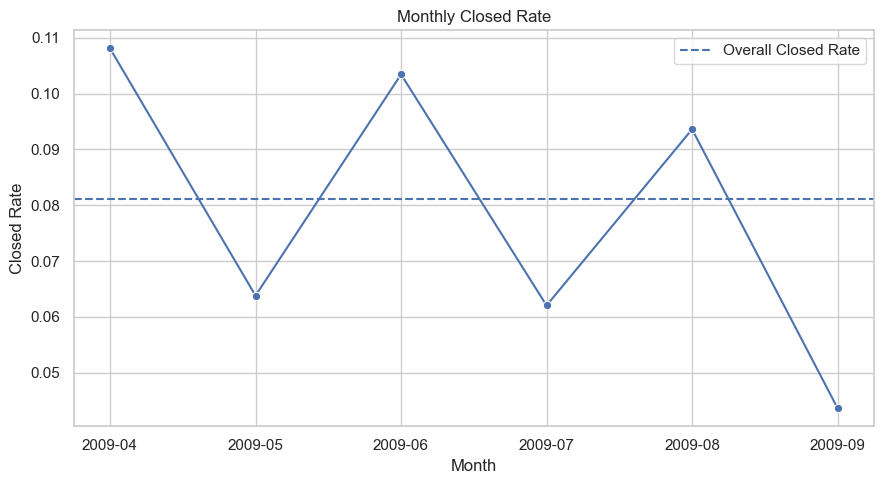

In [6]:
monthly_plot = monthly_quality.reset_index()
monthly_plot["Month"] = monthly_plot["Month"].astype(str)

plt.figure(figsize=(9, 5))
sns.lineplot(data=monthly_plot, x="Month", y="ClosedRate", marker="o")
plt.axhline(observed_closed_rate, linestyle="--", label="Overall Closed Rate")
plt.title("Monthly Closed Rate")
plt.xlabel("Month")
plt.ylabel("Closed Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
monthly_test = monthly_quality.reset_index()
monthly_test["MonthNumber"] = np.arange(1, len(monthly_test) + 1)
slope, intercept, r_value, p_value, std_err = stats.linregress(monthly_test["MonthNumber"], monthly_test["ClosedRate"])

print(f"Slope: {slope:.4f}")
print(f"R²: {r_value ** 2:.4f}")
print(f"P-value: {p_value:.4f}")

Slope: -0.0078
R²: 0.3138
P-value: 0.2476


### Interpretation

- The monthly Closed Rate varies substantially across the six-month observation period, ranging from approximately **4.4% in September** to approximately **10.8% in April**.
- A simple linear trend shows a negative slope of approximately **0.78 percentage points per month**. However, the associated **p-value is approximately 0.248**, which is above the conventional 5% significance threshold.
- Therefore, while the observed monthly rates move downward toward the end of the period, the available data does **not provide sufficient statistical evidence of a systematic decline in lead quality over time**.
- The relatively small number of monthly observations also means that the trend should be interpreted cautiously.

## 5. Drivers of Lead Quality

- The previous analysis identified several dimensions with meaningful differences in observed Closed Rate.
- This section summarizes the most relevant findings across acquisition source, form configuration, and consumer characteristics without treating observational differences as causal effects.

In [8]:
partner_quality = (df.groupby("Partner").agg(TotalLeads=("IsClosed", "size"), ClosedLeads=("IsClosed", "sum")))
partner_quality["ClosedRate"] = (partner_quality["ClosedLeads"] / partner_quality["TotalLeads"])
partner_quality = (partner_quality.query("TotalLeads >= 50").sort_values("ClosedRate", ascending=False))
partner_quality

,TotalLeads,ClosedLeads,ClosedRate
Partner,,,
AdKnowledge,171,21,0.1228
google,979,97,0.0991
Call_Center,271,26,0.0959
yahoo,958,74,0.0772
Google,639,26,0.0407


In [9]:
widget_quality = (df.groupby("WidgetName").agg(TotalLeads=("IsClosed", "size"),ClosedLeads=("IsClosed", "sum")))
widget_quality["ClosedRate"] = (widget_quality["ClosedLeads"] / widget_quality["TotalLeads"])
widget_quality = (widget_quality.query("TotalLeads >= 50").sort_values("ClosedRate", ascending=False))
widget_quality

,TotalLeads,ClosedLeads,ClosedRate
WidgetName,,,
w-300250-DebtReduction1-1DC-CreditSolutions,77,12,0.1558
w-300250-DebtReduction1-1DC-BlueMeter,92,13,0.1413
w-300250-DebtReduction1-1DC-Head2,89,11,0.1236
w-300250-DebtReduction1-1DC,348,34,0.0977
w-302252-DebtReduction1-1DC,272,23,0.0846
w-300250-DebtReduction1-2DC-CreditSolutions,75,6,0.0800
w-302252-DebtReduction1-1DC-yellowarrow-dark,135,10,0.0741
w-302252-DebtReduction1-1DC-CreditSolutions,1054,76,0.0721
w-302252-DebtReduction1-1DC-white,430,31,0.0721


In [10]:
debt_quality = (df.groupby("DebtLevel").agg(TotalLeads=("IsClosed", "size"),ClosedLeads=("IsClosed", "sum")))
debt_quality["ClosedRate"] = (debt_quality["ClosedLeads"] / debt_quality["TotalLeads"])
debt_quality = (debt_quality.query("TotalLeads >= 50").sort_values("ClosedRate", ascending=False))
debt_quality

,TotalLeads,ClosedLeads,ClosedRate
DebtLevel,,,
70001-90000,131,18,0.1374
10001-15000,291,34,0.1168
90000-100000,90,9,0.1000
50001-70000,245,22,0.0898
20001-30000,456,40,0.0877
15001-20000,408,35,0.0858
30001-50000,496,39,0.0786
7500-15000,271,19,0.0701
7500-10000,442,22,0.0498


### Key Findings

**Partner**

- Partner-level performance shows meaningful variation among higher-volume sources. `AdKnowledge` has an observed Closed Rate of approximately **12.3%**, while `google` is approximately **9.9%**, `yahoo` approximately **7.7%**, and `Google` approximately **4.1%**.
- The separate `google` and `Google` categories should be investigated because inconsistent naming may fragment acquisition reporting.

**Widget**

- Widget configurations also show meaningful differences. Several higher-volume widgets have Closed Rates materially above the overall 8.11% baseline. For example, `300250-CreditSolutions` is approximately **15.6%**, while `300250-BlueMeter` is approximately **14.1%**.
- These differences provide useful candidates for controlled creative and form testing.

**Debt Level**

- Debt-level segments vary in observed Closed Rate, with some segments substantially above the overall baseline. For example, `70001-90000` records approximately **13.7%**, while `More_than_100000` records approximately **3.7%**.
- The relationship is not monotonic, so debt level should be treated as a segmentation signal rather than evidence that higher or lower debt itself causes better lead quality.

Overall, the analysis indicates that lead quality is not uniform across acquisition sources, widget configurations, and consumer segments. These differences provide potential optimization signals, but the observational nature of the data means they should be validated through controlled testing.

## 6. Opportunity to Reach 9.6%

- The advertiser's stated target is to increase lead quality from **8.0% to 9.6%**, representing a 20% relative improvement in Closed Rate.
- The dataset's observed baseline is slightly higher at **8.11%**. The analysis therefore uses the actual observed rate as the starting point while retaining 9.6% as the target specified by the assignment.

In [11]:
target_closed_rate = 0.096
required_closed_leads = int(np.ceil(target_closed_rate * total_leads))
additional_closed_leads = (required_closed_leads - closed_leads)
rate_gap = (target_closed_rate - observed_closed_rate)

print(f"Observed Closed Rate: {observed_closed_rate:.2%}")
print(f"Target Closed Rate: {target_closed_rate:.2%}")
print(f"Gap: {rate_gap:.2%}")
print(f"Required Closed Leads: {required_closed_leads:,}")
print(f"Additional Closed Leads Required: {additional_closed_leads:,}")

Observed Closed Rate: 8.11%
Target Closed Rate: 9.60%
Gap: 1.49%
Required Closed Leads: 291
Additional Closed Leads Required: 46


In [12]:
current_cpl = 30
proposed_cpl = 33

cpl_change = (proposed_cpl - current_cpl) / current_cpl

print(f"Current CPL: ${current_cpl:.2f}")
print(f"Proposed CPL: ${proposed_cpl:.2f}")
print(f"Implied CPL Increase: {cpl_change:.1%}")

Current CPL: $30.00
Proposed CPL: $33.00
Implied CPL Increase: 10.0%


### Interpretation

- At the current volume of **3,021 leads**, reaching a 9.6% Closed Rate would require at least **291 Closed leads**.
- The dataset currently contains **245 Closed leads**, meaning approximately **46 additional Closed leads** would be required at the same total lead volume.
- The assignment's quality target is mathematically consistent with a 20% relative improvement: **8.0% × 1.20 = 9.6%**
- However, the stated CPL change from **$30 to $33** represents a **10% increase**, rather than a 20% increase: **($33 - $30) / $30 = 10%**
  
- The analysis therefore retains the assignment's explicit $30/$33 CPL scenario and 9.6% quality target without changing either assumption.

## 7. Recommended Actions

- The analysis identifies several practical areas for improving lead quality.
- These recommendations are based on observed historical differences and should be validated prospectively.

### 1. Test Higher-Performing Widgets

- Several widget configurations show materially higher observed Closed Rates than the overall baseline.
- Run controlled tests comparing these configurations against existing creatives while tracking Closed Rate and sufficient lead volume.

### 2. Optimize Acquisition Sources

- Partner-level differences suggest that traffic source and traffic composition may influence observed lead quality.
- Investigate higher-performing partners and review the characteristics of their traffic before increasing allocation. Lower-performing sources should also be examined for traffic-quality issues.

### 3. Investigate the Characteristics of Higher-Quality Leads

- Debt level and other consumer attributes can be used to understand which types of leads are more likely to become customers.
- These characteristics should be used for segmentation and targeting analysis rather than interpreted as direct causal drivers.

### 4. Standardize Acquisition Reporting

- The separate `google` and `Google` partner categories should be investigated and standardized if they represent the same underlying source.
- Cleaner source definitions will improve future performance comparisons and allocation decisions.

### 5. Validate Through Controlled Testing

- Historical differences do not establish causality.
- The most reliable next step is to run controlled experiments and measure whether changes to traffic allocation or form configuration produce sustained improvements in Closed Rate.

### 6. Monitor Closed Rate and Absolute Conversions

- The target requires approximately **46 additional Closed leads** at the current volume.
- Both Closed Rate and absolute Closed leads should therefore be monitored when evaluating future optimization efforts.

## Overall Findings & Conclusion

The analysis of **3,021 leads** identifies an observed overall Closed Rate of **8.11%**, compared with the advertiser's target of **9.6%**.

### 1. Lead Quality Trend

- Monthly Closed Rate varies considerably throughout the six-month observation period, with rates ranging from approximately **4.4% to 10.8%**.
- Although the fitted trend is negative, with a slope of approximately **-0.78 percentage points per month**, the associated **p-value of 0.248** does not provide sufficient evidence of a statistically significant systematic decline.
- The data therefore shows variation over time, but does not establish a statistically significant deterioration in lead quality.

### 2. Drivers and Segmentation

- Lead quality differs across several dimensions.

- **Partner** shows meaningful variation among higher-volume acquisition sources. `AdKnowledge` records approximately **12.3% Closed Rate**, while `yahoo` is approximately **7.7%** and `Google` approximately **4.1%**.
- **Widget configuration** also shows substantial variation. Some widgets, including `300250-CreditSolutions` and `300250-BlueMeter`, have observed Closed Rates materially above the overall baseline.
- **Debt level** shows additional variation, although the relationship is not monotonic. It is therefore more useful as a segmentation signal than as a standalone explanation for lead quality.
- These findings identify potential optimization areas but do not establish causality.

### 3. Opportunity to Reach 9.6%

- At the current lead volume, reaching the 9.6% target requires at least **291 Closed leads**, compared with the **245 currently observed**.
- This means approximately **46 additional Closed leads** would be required without increasing the total number of leads.
- The dataset contains several higher-performing segments that could provide opportunities for improvement. However, no single segment appears sufficient to independently deliver the required improvement based on its current volume.
- The opportunity is therefore better approached through incremental optimization of acquisition sources and form configurations, supported by controlled experimentation.

### Recommended Path Forward

The most practical approach is to:

1. Test higher-performing widget configurations.
2. Investigate and optimize acquisition partner traffic.
3. Use consumer characteristics such as debt level to understand higher-quality lead profiles.
4. Standardize acquisition-source naming and reporting.
5. Validate historical findings through controlled tests before scaling changes.
6. Monitor both Closed Rate and the absolute number of Closed leads.

Overall, the historical data provides several actionable signals for improving lead quality, but it does not support assuming that any single historical segment will automatically produce the 9.6% target when scaled.

The strongest opportunity is therefore to use the observed segment differences to design targeted experiments, measure the resulting Closed Rate, and iteratively shift traffic toward configurations that demonstrate sustained improvement.